# Stockholm Airbnb Market Analysis

**Project by: Faith Kangogo**

---

## Objective

This project examines the short-term rental market in Stockholm to identify the drivers of nightly price and characterise the host landscape. The goal is to surface patterns useful to a new host setting a competitive price, or to a platform team monitoring market health.

## Data

Data source: [Inside Airbnb](https://insideairbnb.com/get-the-data/), Stockholm, 30 June 2026 snapshot.

One row per active listing, covering price, location, room type, host attributes, and review activity. Prices are nightly rates in SEK. Listings with no recorded price and those above the 99th percentile are excluded as outliers.

## Business questions

1. How are prices distributed across the city?
2. How does price vary by room type (entire home vs private room vs shared)?
3. Which neighbourhoods are most expensive?
4. Who runs the market: casual hosts or professional operators?
5. Hypothesis test: do Superhosts charge significantly more than regular hosts?

## Approach

Data is cleaned in pandas, then queried in SQL (SQLite) for extraction and aggregation, and visualised with matplotlib and seaborn. A Welch's two-sample t-test assesses whether Superhost status is associated with higher pricing.

## Key findings (summary)

1. Prices are highly right-skewed: median 1,918 SEK, with a long premium tail.
2. Entire homes dominate (81% of listings) and average 2.6x the price of private rooms.
3. Sodermalm and the central districts command top prices, though some outer districts rank surprisingly high.
4. About 9 in 10 hosts run a single listing; those hosts supply about two-thirds of all listings.
5. Superhosts average about 5% higher prices, but the difference is not statistically significant (p = 0.09).

---

## 1. Setup and data loading

In [ ]:
# Imports
import os
import sqlite3
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# Consistent minimal styling: one accent blue, greys for everything secondary
BLUE = '#2C7BE5'
DARK_BLUE = '#1B4F8F'
GREY = '#C3CDD7'
TEXT = '#252A31'

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.edgecolor': GREY,
    'text.color': TEXT,
    'axes.labelcolor': TEXT,
    'xtick.color': TEXT,
    'ytick.color': TEXT,
})

print('Libraries loaded')

Libraries loaded


In [ ]:
# Load the data (works whether the file is compressed or not)
DATA_FILE = 'listings.csv.gz' if os.path.exists('listings.csv.gz') else 'listings.csv'
df = pd.read_csv(DATA_FILE)
print(f'Loaded {df.shape[0]:,} listings with {df.shape[1]} columns from {DATA_FILE}')

Loaded 4,806 listings with 90 columns from listings.csv.gz


## 2. Data cleaning

Three steps, mirroring the README:

1. Convert `price` from text (for example `$1,503.50`) to a number.
2. Remove listings with no recorded price or a price of zero.
3. Remove the top 1% of prices as outliers, so a handful of luxury listings do not distort averages.

In [ ]:
# Step 1: price text -> numeric
df['price_num'] = pd.to_numeric(
    df['price'].astype(str).str.replace(r'[$,]', '', regex=True),
    errors='coerce'
)

# Step 2: drop missing and zero prices
listings = df[df['price_num'].notna() & (df['price_num'] > 0)].copy()
dropped_missing = len(df) - len(listings)

# Step 3: drop the top 1% of prices
cutoff_99 = listings['price_num'].quantile(0.99)
listings = listings[listings['price_num'] <= cutoff_99]

# Superhost flag as a readable label
listings['host_type'] = listings['host_is_superhost'].map({'t': 'Superhost', 'f': 'Regular host'})

print(f'Removed {dropped_missing:,} listings with missing or zero price')
print(f'99th percentile cutoff: {cutoff_99:,.0f} SEK')
print(f'Working dataset: {len(listings):,} listings')

Removed 1,542 listings with missing or zero price
99th percentile cutoff: 9,150 SEK
Working dataset: 3,231 listings


## 3. Load into SQLite

The cleaned data goes into an in-memory SQLite database so the aggregation steps can be done in SQL.

In [ ]:
conn = sqlite3.connect(':memory:')
cols = ['id', 'neighbourhood_cleansed', 'room_type', 'price_num', 'host_id', 'host_type']
listings[cols].to_sql('listings', conn, index=False, if_exists='replace')

test = pd.read_sql_query('SELECT COUNT(*) AS n FROM listings', conn)
print(f"SQLite table ready with {test['n'][0]:,} rows")

SQLite table ready with 3,231 rows


## 4. Finding 1: prices are highly right-skewed

Most listings cluster in the low thousands of SEK, with a long tail of premium listings.

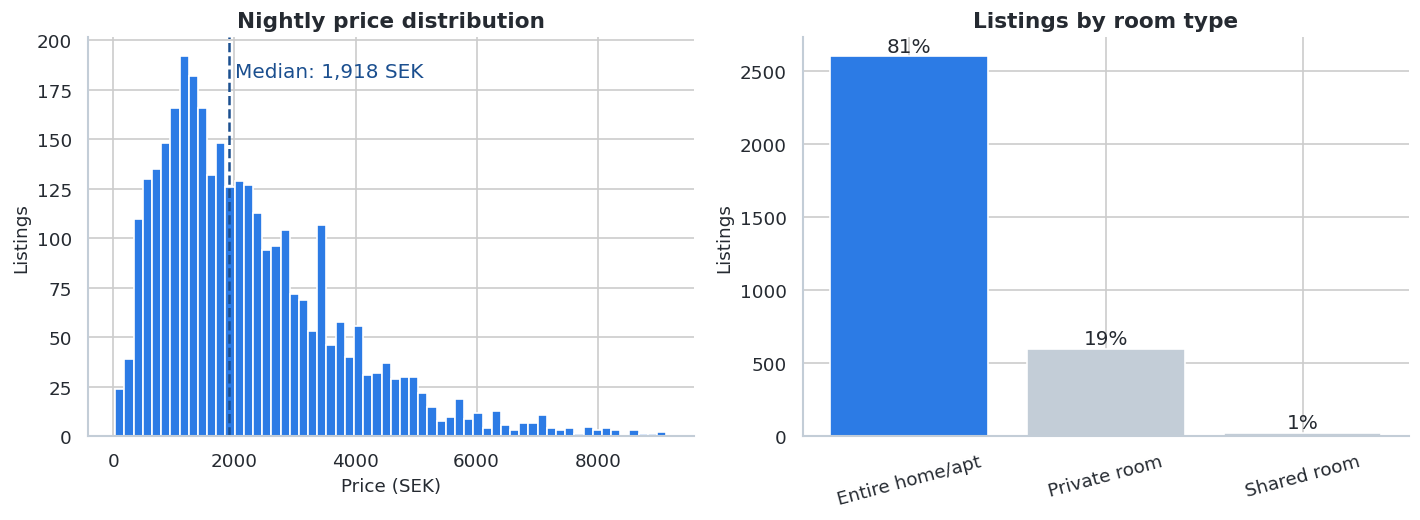

Median: 1,918 SEK | middle 50% of listings: 1,141 to 3,036 SEK


In [ ]:
median_price = listings['price_num'].median()
q1, q3 = listings['price_num'].quantile([0.25, 0.75])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: price distribution
axes[0].hist(listings['price_num'], bins=60, color=BLUE, edgecolor='white')
axes[0].axvline(median_price, color=DARK_BLUE, linestyle='--', linewidth=1.5)
axes[0].text(median_price * 1.05, axes[0].get_ylim()[1] * 0.9,
             f'Median: {median_price:,.0f} SEK', color=DARK_BLUE)
axes[0].set_title('Nightly price distribution')
axes[0].set_xlabel('Price (SEK)')
axes[0].set_ylabel('Listings')

# Right: room type mix
share = listings['room_type'].value_counts()
colors = [BLUE if i == 0 else GREY for i in range(len(share))]
axes[1].bar(share.index, share.values, color=colors, edgecolor='white')
axes[1].set_title('Listings by room type')
axes[1].set_ylabel('Listings')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(share.values):
    axes[1].text(i, v, f'{v / len(listings) * 100:.0f}%', ha='center', va='bottom')

sns.despine()
plt.tight_layout()
plt.savefig('stockholm_price_roomtype_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median: {median_price:,.0f} SEK | middle 50% of listings: {q1:,.0f} to {q3:,.0f} SEK')

**Insight:** the median nightly price is about 1,918 SEK, with half of all listings between roughly 1,100 and 3,000 SEK. Averages in this market are pulled up by the premium tail, so median is the safer reference point for a new host.

## 5. Finding 2: room type is a strong price driver

      room_type  listings  avg_price
Entire home/apt      2604     2570.0
   Private room       601     1002.0
    Shared room        26      568.0

Entire home vs private room average price ratio: 2.6x


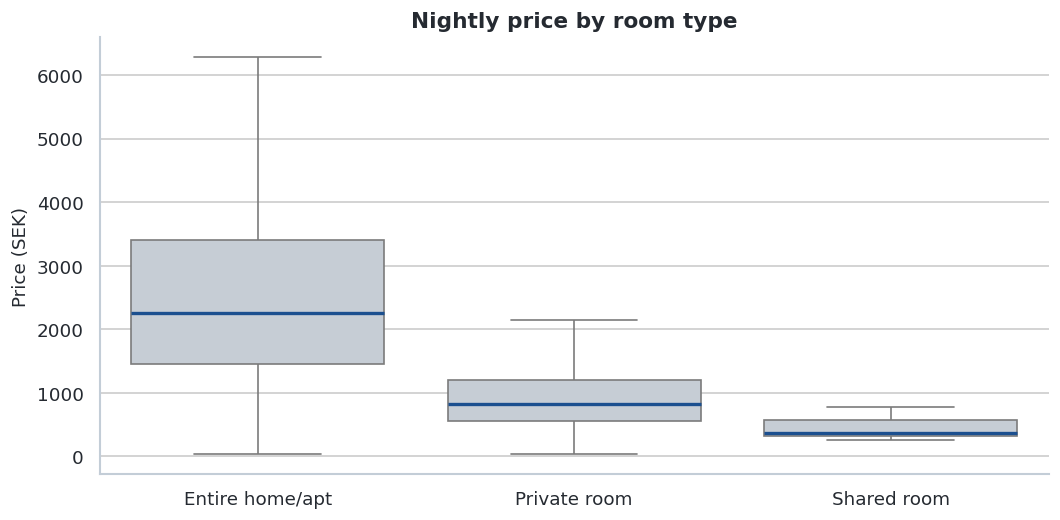

In [ ]:
room_sql = pd.read_sql_query('''
    SELECT room_type,
           COUNT(*)               AS listings,
           ROUND(AVG(price_num))  AS avg_price
    FROM listings
    GROUP BY room_type
    ORDER BY avg_price DESC
''', conn)
print(room_sql.to_string(index=False))

ratio = (room_sql.loc[room_sql.room_type == 'Entire home/apt', 'avg_price'].iloc[0]
         / room_sql.loc[room_sql.room_type == 'Private room', 'avg_price'].iloc[0])
print(f'\nEntire home vs private room average price ratio: {ratio:.1f}x')

order = ['Entire home/apt', 'Private room', 'Shared room']
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=listings, x='room_type', y='price_num', order=order,
            showfliers=False, color=GREY, medianprops={'color': DARK_BLUE, 'linewidth': 2})
ax.set_title('Nightly price by room type')
ax.set_xlabel('')
ax.set_ylabel('Price (SEK)')
sns.despine()
plt.tight_layout()
plt.savefig('price_by_room_type.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** entire homes make up 81% of the market and average about 2.6x the price of private rooms (2,570 vs 1,002 SEK). Room type is the single clearest pricing lever a host controls.

## 6. Finding 3: location matters, as a tendency rather than a rule

         neighbourhood  listings  avg_price
            Södermalms       801     2672.0
                Bromma       215     2510.0
                Farsta       120     2432.0
            Östermalms       223     2418.0
             Norrmalms       325     2321.0
          Kungsholmens       308     2130.0
 Enskede-Årsta-Vantörs       297     2115.0
            Skarpnäcks       134     2062.0
Hägersten-Liljeholmens       294     2054.0
                Älvsjö       157     2000.0
         Spånga-Tensta        77     1958.0
    Hässelby-Vällingby       116     1869.0
        Rinkeby-Tensta        88     1226.0
           Skärholmens        76     1178.0


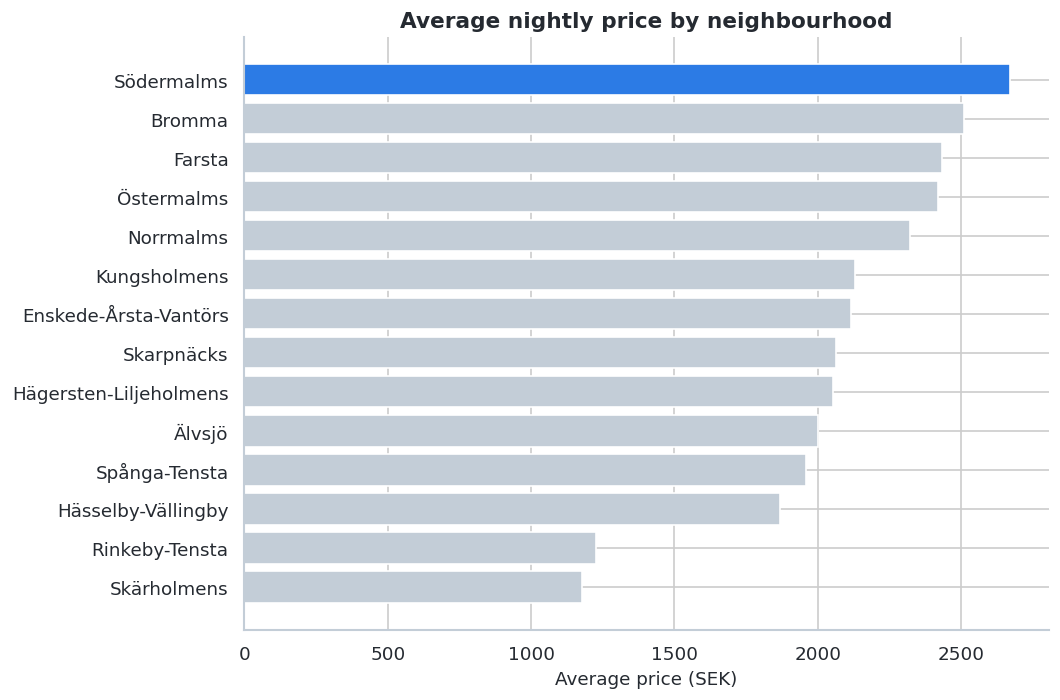

In [ ]:
nbhd = pd.read_sql_query('''
    SELECT neighbourhood_cleansed  AS neighbourhood,
           COUNT(*)                AS listings,
           ROUND(AVG(price_num))   AS avg_price
    FROM listings
    GROUP BY neighbourhood_cleansed
    HAVING COUNT(*) >= 20
    ORDER BY avg_price DESC
''', conn)
print(nbhd.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = [BLUE if i == 0 else GREY for i in range(len(nbhd))]
ax.barh(nbhd['neighbourhood'], nbhd['avg_price'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Average nightly price by neighbourhood')
ax.set_xlabel('Average price (SEK)')
sns.despine()
plt.tight_layout()
plt.savefig('price_by_neighbourhood.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Sodermalm tops the market at about 2,672 SEK, with the premium central districts close behind, while the cheapest outer districts average less than half of that. Some non-central districts (Bromma, Farsta) also rank high, so the centre-to-periphery gradient holds broadly but with exceptions worth investigating.

## 7. Finding 4: hosting is overwhelmingly casual, with a small professional tail

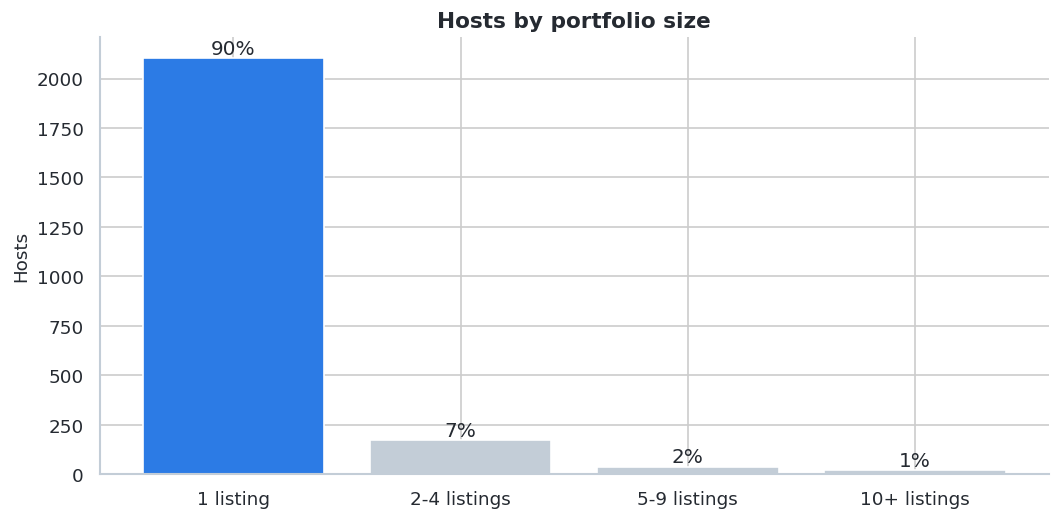

Hosts with a single listing: 90% of all hosts
Share of listings supplied by single-listing hosts: 65%
Largest single portfolio: 52 listings


In [ ]:
host_sql = pd.read_sql_query('''
    SELECT host_id, COUNT(*) AS portfolio
    FROM listings
    GROUP BY host_id
''', conn)

host_sql['bucket'] = pd.cut(host_sql['portfolio'], bins=[0, 1, 4, 9, np.inf],
                            labels=['1 listing', '2-4 listings', '5-9 listings', '10+ listings'])
buckets = host_sql['bucket'].value_counts().reindex(['1 listing', '2-4 listings', '5-9 listings', '10+ listings'])

single_host_share = (host_sql['portfolio'] == 1).mean() * 100
single_listing_share = host_sql.loc[host_sql['portfolio'] == 1, 'portfolio'].sum() / len(listings) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [BLUE] + [GREY] * 3
ax.bar(buckets.index, buckets.values, color=colors, edgecolor='white')
for i, v in enumerate(buckets.values):
    ax.text(i, v, f'{v / len(host_sql) * 100:.0f}%', ha='center', va='bottom')
ax.set_title('Hosts by portfolio size')
ax.set_ylabel('Hosts')
sns.despine()
plt.tight_layout()
plt.savefig('host_types.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Hosts with a single listing: {single_host_share:.0f}% of all hosts')
print(f'Share of listings supplied by single-listing hosts: {single_listing_share:.0f}%')
print(f'Largest single portfolio: {host_sql.portfolio.max()} listings')

**Insight:** about 9 in 10 hosts operate exactly one listing, and together those casual hosts supply roughly two-thirds of the market. A small professional tail exists, with the largest operator managing over 50 listings.

## 8. Finding 5: do Superhosts charge more? (hypothesis test)

Null hypothesis: Superhosts and regular hosts have the same average nightly price. We use Welch's t-test, which does not assume equal variances between the groups.

Superhosts:    n = 745, mean = 2,344 SEK
Regular hosts: n = 2,486, mean = 2,237 SEK
Welch's t-test: t = 1.68, p = 0.094
At the 5% level the difference is NOT significant


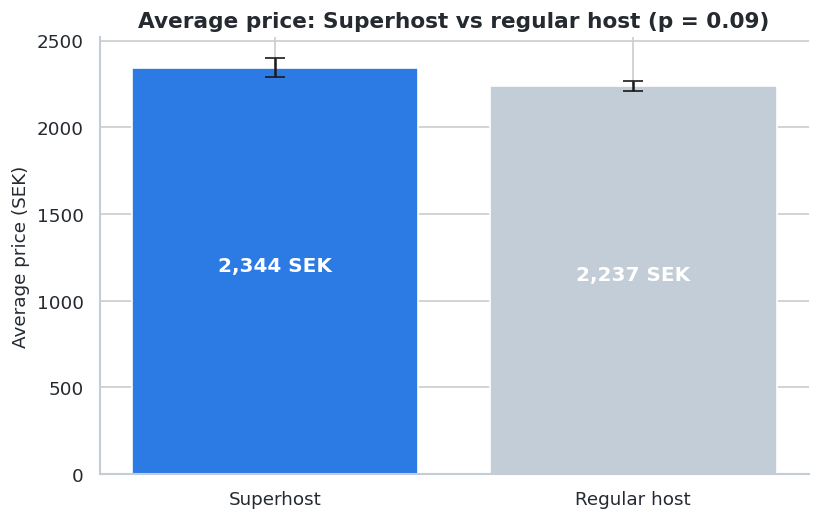

In [ ]:
superhost = listings.loc[listings['host_type'] == 'Superhost', 'price_num']
regular = listings.loc[listings['host_type'] == 'Regular host', 'price_num']

t_stat, p_value = stats.ttest_ind(superhost, regular, equal_var=False)

print(f'Superhosts:    n = {len(superhost):,}, mean = {superhost.mean():,.0f} SEK')
print(f'Regular hosts: n = {len(regular):,}, mean = {regular.mean():,.0f} SEK')
print(f"Welch's t-test: t = {t_stat:.2f}, p = {p_value:.3f}")
verdict = 'significant' if p_value < 0.05 else 'NOT significant'
print(f'At the 5% level the difference is {verdict}')

means = [superhost.mean(), regular.mean()]
errs = [superhost.sem(), regular.sem()]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(['Superhost', 'Regular host'], means, yerr=errs, capsize=6,
       color=[BLUE, GREY], edgecolor='white')
for i, v in enumerate(means):
    ax.text(i, v * 0.5, f'{v:,.0f} SEK', ha='center', color='white', fontweight='bold')
ax.set_title(f'Average price: Superhost vs regular host (p = {p_value:.2f})')
ax.set_ylabel('Average price (SEK)')
sns.despine()
plt.tight_layout()
plt.savefig('superhost_test.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Superhosts average about 5% higher prices (2,344 vs 2,237 SEK), but the difference is not statistically significant at the 5% level (p = 0.09). Superhost status appears to be associated more with guest trust and competitiveness than with a clear pricing premium. Testing occupancy rather than price would be the natural next step.

## 9. Conclusions

1. **Price a listing by room type first.** Entire homes average 2.6x private rooms; this is the largest single factor observed.
2. **Location adds a premium, with nuance.** Sodermalm and the centre lead, but some outer districts also price high, so hosts should benchmark against their own district rather than assume periphery means cheap.
3. **The market is casual.** Roughly 90% of hosts run one listing, supplying about two-thirds of the market; supply is not concentrated among professional operators.
4. **Superhost status is not a pricing licence.** The 5% average premium is not statistically significant; its value likely shows up in bookings, not price.

### Limitations and next steps

- Single snapshot (30 June 2026): summer prices likely run above the annual average, and findings may shift by season.
- Price is the listed rate, not what guests actually paid.
- Next steps: test Superhost status against occupancy, and model price on multiple features (size, location, room type) with regression.